# Sensitivitätsanalyse: Robustheit der Verkehrsmittel-Empfehlung

Dieses Notebook untersucht, **wie empfindlich die empfohlene Modal-Split-Entscheidung**
(Straße / Schiene / Schiff / Luft) auf Änderungen der wichtigsten Modell- und
Datenannahmen reagiert. Damit beantwortet es die Prüffrage der Projektaufgabe:
*„Wie sensitiv ist die Empfehlung gegenüber Änderungen wichtiger Parameter?"*

Untersucht werden drei Parametergruppen:

1. **Zielgewichte** (Kosten / Zeit / Emissionen) — der zentrale Zielkonflikt.
2. **CO₂-Preis** und **modusspezifische Emissions-/Kostenfaktoren**.
3. **Fahrzeugkapazität** (Konsolidierung).

Die dichten Sweeps werden mit der schnellen **A\*-Heuristik** gerechnet (jeder Lauf
wenige Sekunden); der exakte **MILP-Solver** dient an ausgewählten Stützpunkten zur
Validierung. Zwischenergebnisse werden als CSV in `notebooks/results/` zwischengespeichert.

## 1. Setup

In [1]:
import sys, time, random
from pathlib import Path
from collections import defaultdict
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from freight_routing.data_loader import NetworkDataLoader
from freight_routing.data_models import Shipment, ObjectiveWeights, ModeFactor, ArcType
from freight_routing.model import TimeExpandedNetwork, TimeExpandedFreightRoutingModel
from heuristics.dijkstra_router import AStarRouter

sns.set_theme(style="whitegrid", palette="muted")
RESULTS = ROOT / "notebooks" / "results"
RESULTS.mkdir(exist_ok=True)
MODES = ("road", "rail", "ship", "air")
MODE_LABEL = {"road": "Straße", "rail": "Schiene", "ship": "Schiff", "air": "Luft"}

## 2. Instanz und Referenzszenario

Als Testinstanz dient das **kleine Netzwerk** (100 Hubs) mit einem festen Satz von
30 zufälligen, aber reproduzierbaren Sendungen (Seed 1). Entscheidend ist ein
**realistischer Planungshorizont von 60 Tagen**: Da die Hubs global verteilt sind,
benötigt Seefracht interkontinental Wochen. Bei zu kurzen Fristen wäre für weite
Relationen nur die Luftfracht *zulässig* — der Modal Split wäre dann ein reines
Feasibility-Artefakt und nicht das Ergebnis einer echten Abwägung.

In [2]:
network_data = NetworkDataLoader.from_json(ROOT / "dataset" / "small_network.json")
PLANNING_DAYS = 60
N_SHIPMENTS = 30
SEED = 1


def build_shipments(nd, n, days, seed=SEED, weight_range=(5, 25)):
    """Reproducible shipments; objective weights are left unset so the weight
    vector passed to the router controls the trade-off uniformly."""
    rng = random.Random(seed)
    hubs = list(nd.hubs.keys())
    deadline = days * 24 * 60
    out = []
    for i in range(n):
        s = rng.choice(hubs)
        d = rng.choice(hubs)
        while d == s:
            d = rng.choice(hubs)
        out.append(Shipment(id=f"s{i}", start_hub=s, end_hub=d, start_time=0,
                            deadline=deadline, max_price=1e9, max_emissions=None,
                            weight=float(rng.randint(*weight_range))))
    return out


shipments = build_shipments(network_data, N_SHIPMENTS, PLANNING_DAYS)
base_network = TimeExpandedNetwork.build(network_data, planning_days=PLANNING_DAYS,
                                         shipments=shipments)
print(f"{len(shipments)} Sendungen | Horizont {PLANNING_DAYS} Tage | "
      f"Netz: {len(base_network.nodes):,} Knoten / {len(base_network.all_arcs):,} Kanten")
print("Baseline-Faktoren (cost / emiss je t-km):")
for m in MODES:
    f = network_data.mode_factors[m]
    print(f"  {MODE_LABEL[m]:8s} {f.cost_per_ton_km:5.2f} €  {f.emissions_kg_per_ton_km:5.3f} kg")

30 Sendungen | Horizont 60 Tage | Netz: 500,776 Knoten / 877,525 Kanten
Baseline-Faktoren (cost / emiss je t-km):
  Straße    1.20 €  0.090 kg
  Schiene   0.70 €  0.025 kg
  Schiff    0.40 €  0.015 kg
  Luft      3.50 €  0.600 kg


## 3. Hilfsfunktionen

Alle Parameter-Störungen erzeugen über `dataclasses.replace` eine **neue** Netzwerk-
Konfiguration und lassen die Baseline unverändert. `metrics()` extrahiert den
Modal Split (ton-km je Modus) sowie die aggregierten Kennzahlen aus einem Routing-Ergebnis.

In [3]:
def scale_mode_factors(nd, modes=MODES, cost_scale=1.0, emissions_scale=1.0):
    nf = dict(nd.mode_factors)
    for m in modes:
        f = nf.get(m)
        if f:
            nf[m] = ModeFactor(f.cost_per_ton_km * cost_scale,
                               f.emissions_kg_per_ton_km * emissions_scale)
    return replace(nd, mode_factors=nf)


def apply_carbon_price(nd, price_per_kg):
    """Internalize a CO2 price: cost' = cost + price * emissions. Emission
    factors stay untouched, so total_emissions still reports physical emissions."""
    nf = {m: ModeFactor(f.cost_per_ton_km + price_per_kg * f.emissions_kg_per_ton_km,
                        f.emissions_kg_per_ton_km)
          for m, f in nd.mode_factors.items()}
    return replace(nd, mode_factors=nf)


def scale_capacity(nd, scale, modes=MODES):
    nc = dict(nd.capacities)
    for m in modes:
        if m in nc:
            nc[m] = nc[m] * scale
    return replace(nd, capacities=nc)


def metrics(result, ships):
    weight_by_id = {s.id: s.weight for s in ships}
    tonkm = defaultdict(float)
    users = defaultdict(set)
    for s_id, route in result.shipment_routes.items():
        w = weight_by_id[s_id]
        for a in route:
            if a.arc_type == ArcType.TRANSPORT:
                tonkm[a.mode] += w * a.distance
                users[a].add(s_id)
    total = sum(tonkm.values()) or 1.0
    consolidated = {s for u in users.values() if len(u) >= 2 for s in u}
    solved = len(result.shipment_routes)
    m = {"solved": solved, "objective": result.objective_value,
         "total_cost": result.total_cost, "total_emissions": result.total_emissions,
         "total_time": result.total_time,
         "consolidation_rate": len(consolidated) / solved if solved else 0.0}
    for mode in MODES:
        m[f"share_{mode}"] = tonkm.get(mode, 0.0) / total
    return m


def run_heuristic(nd, weights, network=None, ships=None, days=PLANNING_DAYS):
    ships = shipments if ships is None else ships
    net = network or TimeExpandedNetwork.build(nd, planning_days=days, shipments=ships)
    t = time.perf_counter()
    res = AStarRouter(objective_weights=weights).solve_multiple(net)
    m = metrics(res, ships)
    m.update(method="heuristic", runtime=time.perf_counter() - t, status=res.status)
    return m


def run_solver(nd, weights, ships, days, time_limit=200):
    net = TimeExpandedNetwork.build(nd, planning_days=days, shipments=ships)
    t = time.perf_counter()
    res = TimeExpandedFreightRoutingModel(objective_weights=weights).solve(
        net, time_limit_sec=time_limit)
    m = metrics(res, ships)
    m.update(method="solver", runtime=time.perf_counter() - t, status=res.status,
             num_variables=res.num_binary_vars + res.num_integer_vars + res.num_continuous_vars,
             num_constraints=res.num_constraints)
    return m

## 4. Analyse A — Zielgewichte

Zwei eindimensionale Sweeps durch den Gewichts-Simplex (Netz einmal gebaut, nur die
Gewichte variieren):

- **A1 — Kosten ↔ Emissionen** (Zeitgewicht = 0): Prüft, ob zwischen Kosten und
  Emissionen ein Konflikt besteht.
- **A2 — Nachhaltigkeit ↔ Zeit**: Gewicht wandert von je ½ auf Kosten und Emissionen
  hin zu reinem Zeitfokus. Das ist der eigentliche Zielkonflikt.

In [4]:
csv_a = RESULTS / "sens_weights.csv"
if csv_a.exists():
    df_a = pd.read_csv(csv_a)
else:
    rows = []
    grid = np.round(np.linspace(0, 1, 11), 3)
    for t in grid:  # A1: cost <-> emissions, time = 0
        w = ObjectiveWeights(cost=max(1 - t, 1e-6), time=1e-6, emissions=max(t, 1e-6))
        r = run_heuristic(network_data, w, network=base_network)
        r.update(sweep="cost_emiss", t=t)
        rows.append(r)
    for t in grid:  # A2: (cost+emiss) <-> time
        w = ObjectiveWeights(cost=max((1 - t) / 2, 1e-6), time=max(t, 1e-6),
                             emissions=max((1 - t) / 2, 1e-6))
        r = run_heuristic(network_data, w, network=base_network)
        r.update(sweep="sustain_time", t=t)
        rows.append(r)
    df_a = pd.DataFrame(rows)
    df_a.to_csv(csv_a, index=False)
df_a[["sweep", "t", "total_cost", "total_emissions", "total_time",
      "share_ship", "share_air", "consolidation_rate"]].round(3)

,sweep,t,total_cost,total_emissions,total_time,share_ship,share_air,consolidation_rate
0,cost_emiss,0.0,5.536092e+06,715994.184,713231,0.702,0.221,0.483
1,cost_emiss,0.1,5.535100e+06,716032.464,711791,0.702,0.221,0.414
2,cost_emiss,0.2,5.535085e+06,716366.552,711791,0.702,0.221,0.379
3,cost_emiss,0.3,5.534785e+06,716306.552,711791,0.702,0.221,0.414
4,cost_emiss,0.4,5.537980e+06,716076.552,716171,0.702,0.221,0.448
5,cost_emiss,0.5,5.539363e+06,715887.348,716111,0.702,0.221,0.414
6,cost_emiss,0.6,5.542779e+06,715619.188,724751,0.702,0.221,0.448
7,cost_emiss,0.7,5.543185e+06,714547.404,721871,0.701,0.220,0.448
8,cost_emiss,0.8,5.549300e+06,713836.427,723611,0.698,0.219,0.448
9,cost_emiss,0.9,5.563860e+06,713716.427,741851,0.698,0.219,0.517


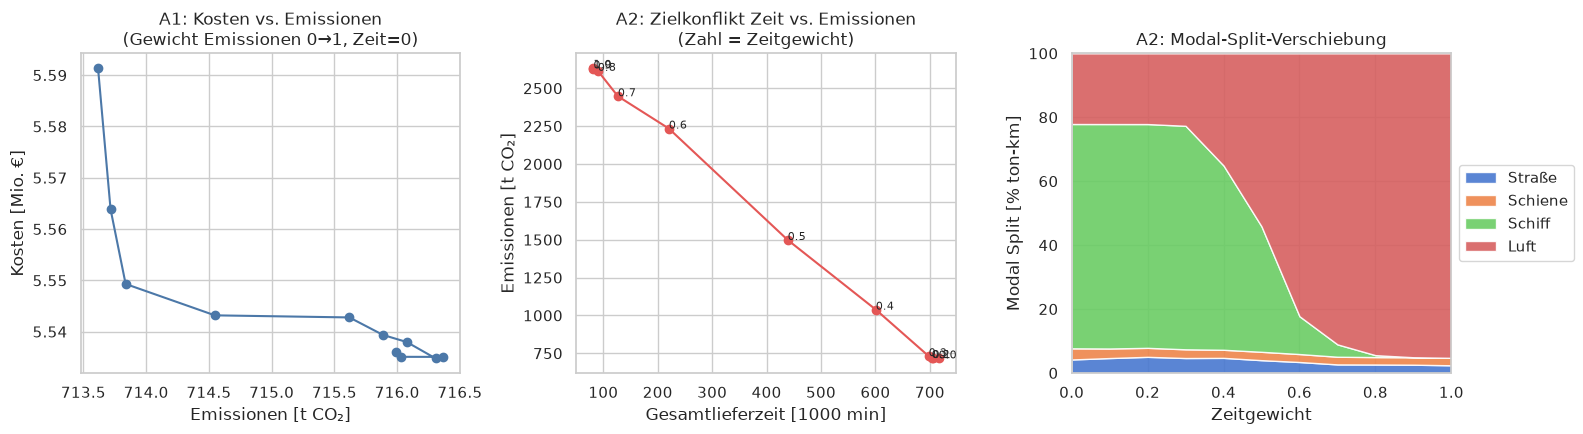

In [5]:
ce = df_a[df_a.sweep == "cost_emiss"].sort_values("t")
st = df_a[df_a.sweep == "sustain_time"].sort_values("t")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

# A1: cost vs emissions -> aligned (both minimized by ship)?
ax[0].plot(ce.total_emissions / 1e3, ce.total_cost / 1e6, "-o", color="#4C78A8")
ax[0].set_xlabel("Emissionen [t CO₂]")
ax[0].set_ylabel("Kosten [Mio. €]")
ax[0].set_title("A1: Kosten vs. Emissionen\n(Gewicht Emissionen 0→1, Zeit=0)")

# A2: the real trade-off -> time vs emissions
ax[1].plot(st.total_time / 1e3, st.total_emissions / 1e3, "-o", color="#E45756")
for _, r in st.iterrows():
    ax[1].annotate(f"{r.t:.1f}", (r.total_time / 1e3, r.total_emissions / 1e3), fontsize=8)
ax[1].set_xlabel("Gesamtlieferzeit [1000 min]")
ax[1].set_ylabel("Emissionen [t CO₂]")
ax[1].set_title("A2: Zielkonflikt Zeit vs. Emissionen\n(Zahl = Zeitgewicht)")

# A2: modal split shift
shares = st[[f"share_{m}" for m in MODES]].values.T * 100
ax[2].stackplot(st.t, *shares, labels=[MODE_LABEL[m] for m in MODES], alpha=0.9)
ax[2].set_xlabel("Zeitgewicht")
ax[2].set_ylabel("Modal Split [% ton-km]")
ax[2].set_title("A2: Modal-Split-Verschiebung")
ax[2].set_xlim(0, 1)
ax[2].set_ylim(0, 100)
ax[2].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.savefig(RESULTS / "fig_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Analyse B — CO₂-Preis und Faktor-Sensitivität

**B1 — CO₂-Preis:** Die Zielfunktion wird rein kostenbasiert gewählt, die Emissionen
werden über einen internalisierten CO₂-Preis (€/kg) in die Kosten eingerechnet. So wird
sichtbar, ab welchem Preis eine kostenminimierende Firma freiwillig emissionsärmer fährt.

**B2 — Faktor-Tornado:** One-at-a-time-Störung (±30 %) einzelner modusspezifischer
Kosten-/Emissionsfaktoren um die Baseline (Gewichte 0.4/0.3/0.3).

In [6]:
csv_b1 = RESULTS / "sens_carbon.csv"
if csv_b1.exists():
    df_b1 = pd.read_csv(csv_b1)
else:
    rows = []
    w_cost = ObjectiveWeights(cost=1.0, time=1e-6, emissions=1e-6)
    for p in [0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]:
        r = run_heuristic(apply_carbon_price(network_data, p), w_cost)
        r["price"] = p
        rows.append(r)
    df_b1 = pd.DataFrame(rows)
    df_b1.to_csv(csv_b1, index=False)
df_b1[["price", "total_cost", "total_emissions", "share_ship", "share_air"]].round(3)

,price,total_cost,total_emissions,share_ship,share_air
0,0.00,5536091.530,715994.184,0.702,0.221
1,0.05,5570451.553,716293.388,0.703,0.221
2,0.10,5606444.948,716024.184,0.702,0.221
3,0.20,5676731.376,715788.231,0.702,0.221
4,0.30,5744318.790,716221.668,0.702,0.221
5,0.50,5884844.124,716251.668,0.702,0.221
6,0.75,6061519.784,716062.464,0.702,0.221
7,1.00,6235944.958,716261.668,0.702,0.221
8,1.50,6587789.132,716062.464,0.702,0.221
9,2.00,6937835.364,715922.464,0.702,0.221


In [7]:
csv_b2 = RESULTS / "sens_factors.csv"
if csv_b2.exists():
    df_b2 = pd.read_csv(csv_b2)
else:
    w = ObjectiveWeights(cost=0.4, time=0.3, emissions=0.3)
    base = run_heuristic(network_data, w, network=base_network)
    base["label"] = "Baseline"
    rows = [base]
    perts = [
        ("Schiene Emiss. -30%", dict(modes=("rail",), emissions_scale=0.7)),
        ("Schiene Kosten -30%", dict(modes=("rail",), cost_scale=0.7)),
        ("Straße Emiss. +30%", dict(modes=("road",), emissions_scale=1.3)),
        ("Schiff Kosten +30%", dict(modes=("ship",), cost_scale=1.3)),
        ("Luft Kosten -30%", dict(modes=("air",), cost_scale=0.7)),
        ("Alle Emiss. +30%", dict(modes=MODES, emissions_scale=1.3)),
    ]
    for label, kw in perts:
        r = run_heuristic(scale_mode_factors(network_data, **kw), w)
        r["label"] = label
        rows.append(r)
    df_b2 = pd.DataFrame(rows)
    df_b2.to_csv(csv_b2, index=False)
df_b2[["label", "total_cost", "total_emissions", "share_road", "share_rail",
       "share_ship", "share_air"]].round(3)

,label,total_cost,total_emissions,share_road,share_rail,share_ship,share_air
0,Baseline,5592097.873,730634.150,0.046,0.028,0.699,0.227
1,Schiene Emiss. -30%,5592097.873,729632.261,0.046,0.028,0.699,0.227
2,Schiene Kosten -30%,5562783.624,730559.266,0.046,0.029,0.699,0.227
3,Straße Emiss. +30%,5591105.673,736374.416,0.046,0.029,0.699,0.227
4,Schiff Kosten +30%,5989828.437,730757.040,0.047,0.027,0.699,0.227
5,Luft Kosten -30%,4486539.620,740596.090,0.046,0.027,0.697,0.231
6,Alle Emiss. +30%,5591255.673,945336.546,0.046,0.029,0.699,0.227


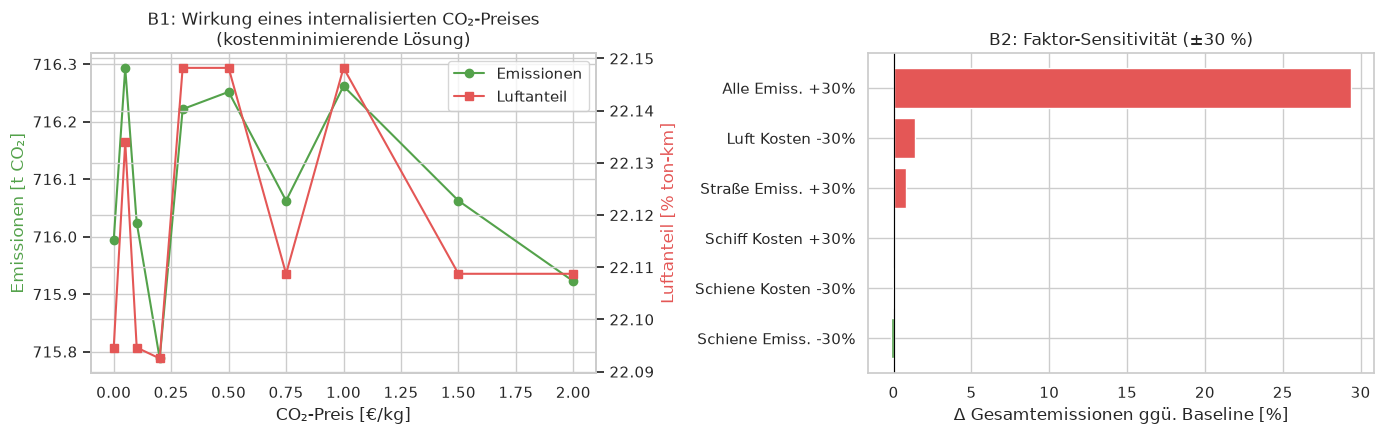

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# B1: carbon price effect
d = df_b1.sort_values("price")
ax2 = ax[0].twinx()
l1, = ax[0].plot(d.price, d.total_emissions / 1e3, "-o", color="#54A24B", label="Emissionen")
l2, = ax2.plot(d.price, d.share_air * 100, "-s", color="#E45756", label="Luftanteil")
ax[0].set_xlabel("CO₂-Preis [€/kg]")
ax[0].set_ylabel("Emissionen [t CO₂]", color="#54A24B")
ax2.set_ylabel("Luftanteil [% ton-km]", color="#E45756")
ax[0].set_title("B1: Wirkung eines internalisierten CO₂-Preises\n(kostenminimierende Lösung)")
ax[0].legend(handles=[l1, l2], loc="upper right")

# B2: tornado of emissions change vs baseline
base_em = df_b2.loc[df_b2.label == "Baseline", "total_emissions"].iloc[0]
d2 = df_b2[df_b2.label != "Baseline"].copy()
d2["delta_pct"] = (d2.total_emissions - base_em) / base_em * 100
d2 = d2.sort_values("delta_pct")
colors = ["#54A24B" if v < 0 else "#E45756" for v in d2.delta_pct]
ax[1].barh(d2.label, d2.delta_pct, color=colors)
ax[1].axvline(0, color="black", lw=0.8)
ax[1].set_xlabel("Δ Gesamtemissionen ggü. Baseline [%]")
ax[1].set_title("B2: Faktor-Sensitivität (±30 %)")

plt.tight_layout()
plt.savefig(RESULTS / "fig_carbon_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Analyse C — Kapazität und Konsolidierung

Skalierung der Fahrzeugkapazitäten aller Modi (Faktor 0,25×–4×) bei festen Gewichten
(0.4/0.3/0.3). Untersucht wird, wie stark Konsolidierungsrate und Modal Split von der
angenommenen Fahrzeuggröße abhängen. Zu beachten ist die **Abdeckung** (Anteil lösbarer
Sendungen): Bei stark reduzierter Kapazität werden einzelne Sendungen infeasibel, sodass
die übrigen Kennzahlen dann auf einer kleineren Sendungsmenge beruhen.

In [9]:
csv_c = RESULTS / "sens_capacity.csv"
if csv_c.exists():
    df_c = pd.read_csv(csv_c)
else:
    rows = []
    w = ObjectiveWeights(cost=0.4, time=0.3, emissions=0.3)
    for sc in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 4.0]:
        r = run_heuristic(scale_capacity(network_data, sc), w)
        r["cap_scale"] = sc
        rows.append(r)
    df_c = pd.DataFrame(rows)
    df_c.to_csv(csv_c, index=False)
df_c[["cap_scale", "solved", "total_cost", "consolidation_rate", "share_ship", "share_air"]].round(3)

,cap_scale,solved,total_cost,consolidation_rate,share_ship,share_air
0,0.25,17,1362641.317,0.000,0.847,0.072
1,0.50,29,5594947.873,0.276,0.699,0.227
2,0.75,29,5593597.873,0.345,0.699,0.227
3,1.00,29,5592097.873,0.414,0.699,0.227
4,1.50,29,5591947.873,0.414,0.699,0.227
5,2.00,29,5591947.873,0.414,0.699,0.227
6,4.00,29,5591947.873,0.414,0.699,0.227


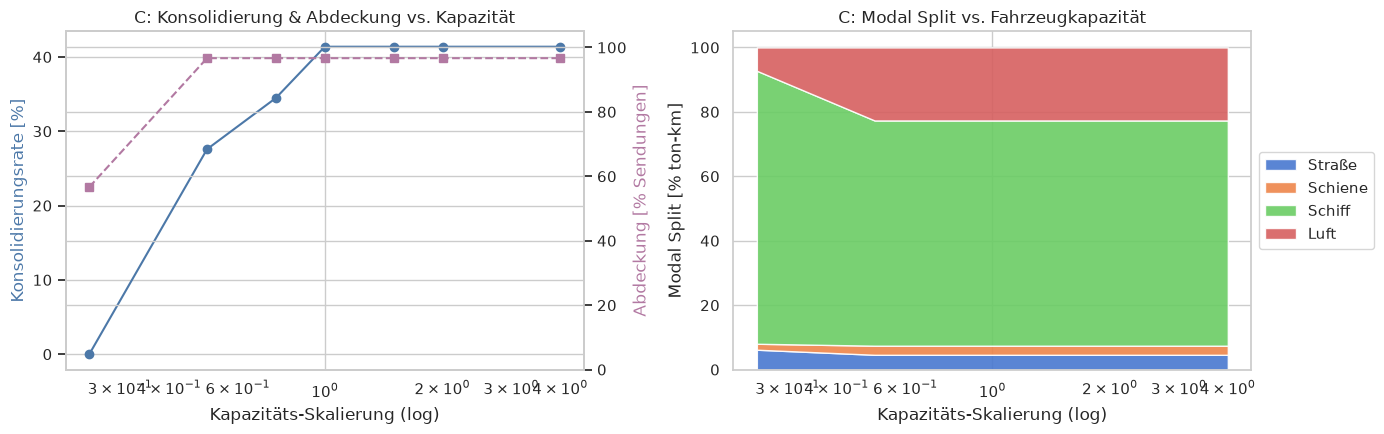

In [10]:
d = df_c.sort_values("cap_scale")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(d.cap_scale, d.consolidation_rate * 100, "-o", color="#4C78A8",
           label="Konsolidierung")
cov = ax[0].twinx()
cov.plot(d.cap_scale, d.solved / N_SHIPMENTS * 100, "--s", color="#B279A2",
         label="Abdeckung")
cov.set_ylabel("Abdeckung [% Sendungen]", color="#B279A2")
cov.set_ylim(0, 105)
ax[0].set_xscale("log")
ax[0].set_xlabel("Kapazitäts-Skalierung (log)")
ax[0].set_ylabel("Konsolidierungsrate [%]", color="#4C78A8")
ax[0].set_title("C: Konsolidierung & Abdeckung vs. Kapazität")

shares = d[[f"share_{m}" for m in MODES]].values.T * 100
ax[1].stackplot(d.cap_scale, *shares, labels=[MODE_LABEL[m] for m in MODES], alpha=0.9)
ax[1].set_xscale("log")
ax[1].set_xlabel("Kapazitäts-Skalierung (log)")
ax[1].set_ylabel("Modal Split [% ton-km]")
ax[1].set_title("C: Modal Split vs. Fahrzeugkapazität")
ax[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(RESULTS / "fig_capacity.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Solver-Validierung (Stützpunkte)

Zur Absicherung, dass die Heuristik das Optimum trifft, wird an zwei Gewichtungen der
exakte MILP-Solver gerechnet. Wegen der Modellgröße geschieht dies auf einer **kleinen,
handhabbaren Instanz** (6 Sendungen, kurzer Horizont). Der Solver liefert das Optimum,
die Heuristik erreicht denselben Zielwert in einem Bruchteil der Zeit.

In [11]:
csv_s = RESULTS / "solver_anchor.csv"
if csv_s.exists():
    df_s = pd.read_csv(csv_s)
else:
    ships_small = build_shipments(network_data, 6, 4, seed=1)
    rows = []
    for name, w in [("kostenorientiert", ObjectiveWeights(1.0, 1e-6, 1e-6)),
                    ("ausgewogen", ObjectiveWeights(0.4, 0.3, 0.3))]:
        mh = run_heuristic(network_data, w, ships=ships_small, days=4)
        mh["scenario"] = name
        ms = run_solver(network_data, w, ships=ships_small, days=4, time_limit=200)
        ms["scenario"] = name
        rows += [mh, ms]
    df_s = pd.DataFrame(rows)
    df_s.to_csv(csv_s, index=False)
df_s[["scenario", "method", "objective", "total_cost", "total_emissions",
      "runtime", "status"]].round(4)

,scenario,method,objective,total_cost,total_emissions,runtime,status
0,kostenorientiert,heuristic,3.1647,2.600141e+06,439071.430,0.3780,Feasible
1,kostenorientiert,solver,3.1647,2.600141e+06,439071.430,128.3317,Optimal
2,ausgewogen,heuristic,2.9321,2.626005e+06,447087.425,0.1424,Feasible
3,ausgewogen,solver,2.9321,2.626005e+06,447087.425,97.5458,Optimal


## 8. Interpretation

- **Kein Konflikt Kosten ↔ Emissionen (A1):** Seefracht ist im Netz gleichzeitig der
  günstigste *und* emissionsärmste Modus. Kosten- und emissionsminimale Lösungen fallen
  praktisch zusammen.
- **Der eigentliche Zielkonflikt ist Geschwindigkeit ↔ Nachhaltigkeit (A2):** Erst ein
  hohes Zeitgewicht verschiebt den Modal Split spürbar von Schiff zu Luft — auf Kosten
  stark steigender Emissionen und Kosten. Hier ist die Empfehlung am sensibelsten.
- **CO₂-Preis (B1):** Selbst ein hoher Preis (bis 2 €/kg) lässt den Modal Split praktisch
  **unverändert** und senkt die Emissionen nicht. Der verbleibende Luftanteil (~22 %) ist
  *feasibility-locked*: Für diese Relationen existiert innerhalb der Frist keine
  emissionsärmere Alternative. Ein reiner CO₂-Preis ist hier wirkungslos — nötig wären
  längere Vorlaufzeiten bzw. bessere Anbindung, nicht nur ein Preissignal.
- **Faktor-Robustheit (B2):** Gegen ±30 % Störungen einzelner Faktoren ist der Modal Split
  stabil; nur eine flächige Emissionsfaktor-Erhöhung skaliert die Gesamtemissionen mechanisch mit.
- **Kapazität (C):** Für Kapazität ≥ Baseline ist die Lösung völlig robust. Erst eine
  drastische Reduktion (0,25×) bricht Konsolidierung *und* Abdeckung ein (nur 17 von 30
  Sendungen lösbar) — die dortigen Kosten-/Split-Werte beruhen daher auf einer kleineren
  Sendungsmenge und sind nicht direkt vergleichbar.
- **Solver-Validierung:** An den Stützpunkten trifft die Heuristik den exakten Zielwert
  (Abweichung 0), ist aber ~300–700× schneller (0,1–0,4 s vs. 98–128 s).
- **Managementempfehlung:** Solange keine engen Lieferfristen bestehen, ist die
  schiffsbasierte, konsolidierte Lösung sowohl kostenoptimal als auch emissionsarm.
  Zeitkritische Sendungen sollten gezielt (nicht pauschal) auf Luftfracht gelegt werden;
  ein CO₂-Preis allein verlagert nichts, wenn schnelle Alternativen fehlen.